# Display D-vs-T Heatmap Results

Notebook version of `display_heat_map_data_D_vs_T.m`. It reads the generated success matrix, overlays the predicted `D_min` line, and optionally displays the bound `c` used for success judgement.

In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

%matplotlib inline

## Parameters

These values should match the parameters used when generating the heatmap files.

In [ ]:
# File name parameters
n = 100
q = 0.8
beta = 0.005
D_min = 1
D_max = 30
c = 1e-3
num_samples = 10
T_intervals = 1000
T_max = 20000
corruption_type = "sup_c"

# Use "fixed" for the old success judgement, or "bound" for per-cell c.
# c_success_mode = "bound"
# maximize_c_for_success = True
c_success_mode = "bound"
maximize_c_for_success = True

## Locate Files

In [25]:
notebook_dir = Path.cwd()
if notebook_dir.name == "heatmap_data_display":
    repo_root = notebook_dir.parent
else:
    repo_root = notebook_dir

data_dir = repo_root / "heat_map_raw_data"
beta_for_filename = np.floor(beta * 100) / 100

base_suffix = (
    f"__n={n}"
    f"__q={q * 100:.0f}"
    f"__beta={beta_for_filename * 100:.0f}"
    f"__D_min={D_min}"
    f"__D_max={D_max}"
    f"__c={c:1.0e}"
    f"__num_samples={num_samples}"
    f"__T_intervals={T_intervals}"
    f"__T_max={T_max}"
    f"__corruption_type={corruption_type}"
)

if c_success_mode == "fixed":
    c_success_suffix = ""
else:
    c_success_suffix = f"__c_success={c_success_mode}__max_c={maximize_c_for_success}"

success_path = data_dir / f"D_vs_T{base_suffix}{c_success_suffix}.txt"
d_min_path = data_dir / f"D_vs_T__D_MIN{base_suffix}.txt"
c_bound_path = data_dir / f"D_vs_T__c_bound{base_suffix}{c_success_suffix}.txt"

print("success_path:", success_path)
print("d_min_path:", d_min_path)
print("c_bound_path:", c_bound_path)

for path in [success_path, d_min_path]:
    if not path.exists():
        raise FileNotFoundError(path)

print("c_bound exists:", c_bound_path.exists())

success_path: /Users/wutong/Documents/LearningNote/PRKm/68712762506e6475ec091584/codes/adv_D_upper/heat_map_raw_data/D_vs_T__n=100__q=80__beta=0__D_min=1__D_max=30__c=1e-03__num_samples=20__T_intervals=100__T_max=20000__corruption_type=sup_c__c_success=bound__max_c=True.txt
d_min_path: /Users/wutong/Documents/LearningNote/PRKm/68712762506e6475ec091584/codes/adv_D_upper/heat_map_raw_data/D_vs_T__D_MIN__n=100__q=80__beta=0__D_min=1__D_max=30__c=1e-03__num_samples=20__T_intervals=100__T_max=20000__corruption_type=sup_c.txt
c_bound_path: /Users/wutong/Documents/LearningNote/PRKm/68712762506e6475ec091584/codes/adv_D_upper/heat_map_raw_data/D_vs_T__c_bound__n=100__q=80__beta=0__D_min=1__D_max=30__c=1e-03__num_samples=20__T_intervals=100__T_max=20000__corruption_type=sup_c__c_success=bound__max_c=True.txt
c_bound exists: True


If the exact parameters do not match, this helper lists existing D-vs-T result files.

In [26]:
result_files = sorted(path.name for path in data_dir.glob("D_vs_T*.txt"))
if pd is not None:
    display(pd.DataFrame({"file": result_files}))
else:
    for name in result_files:
        print(name)

,file
0,D_vs_T__D_MIN__n=100__q=80__beta=0__D_min=1__D...
1,D_vs_T__D_MIN__n=100__q=80__beta=0__D_min=1__D...
2,D_vs_T__c_bound__n=100__q=80__beta=0__D_min=1_...
3,D_vs_T__c_bound__n=100__q=80__beta=0__D_min=1_...
4,D_vs_T__n=100__q=80__beta=0__D_min=1__D_max=30...
5,D_vs_T__n=100__q=80__beta=0__D_min=1__D_max=30...
6,D_vs_T__n=100__q=80__beta=0__D_min=1__D_max=30...


## Load Data

In [27]:
success = np.loadtxt(success_path)
d_min_vals = np.loadtxt(d_min_path)
c_bound = np.loadtxt(c_bound_path) if c_bound_path.exists() else None

success = np.atleast_2d(success)
d_min_vals = np.ravel(d_min_vals)
if c_bound is not None:
    c_bound = np.atleast_2d(c_bound)

T_values = np.arange(T_intervals, T_max + T_intervals, T_intervals)
D_values = np.arange(D_min, D_max + 1)

print("success shape:", success.shape)
print("D_min shape:", d_min_vals.shape)
if c_bound is not None:
    print("c_bound shape:", c_bound.shape)

success shape: (30, 200)
D_min shape: (200,)
c_bound shape: (30, 200)


## Success Heatmap

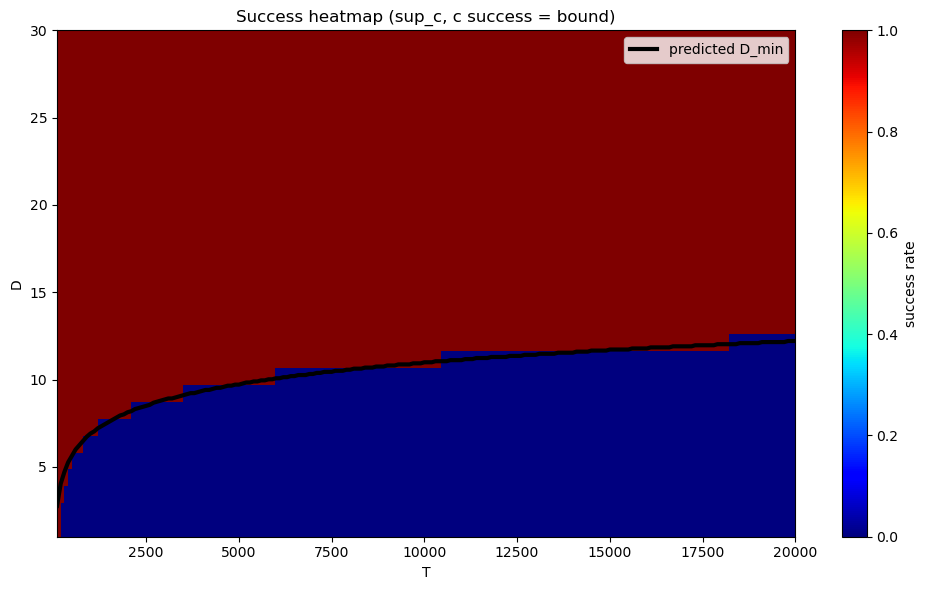

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
image = ax.imshow(
    success,
    aspect="auto",
    origin="lower",
    extent=[T_values[0], T_values[-1], D_values[0], D_values[-1]],
    vmin=0,
    vmax=1,
    cmap="jet",
)
ax.plot(T_values, d_min_vals, linewidth=3, color="black", label="predicted D_min")
fig.colorbar(image, ax=ax, label="success rate")
ax.set_title(f"Success heatmap ({corruption_type}, c success = {c_success_mode})")
ax.set_xlabel("T")
ax.set_ylabel("D")
ax.legend()
plt.tight_layout()

## Bound c Heatmap

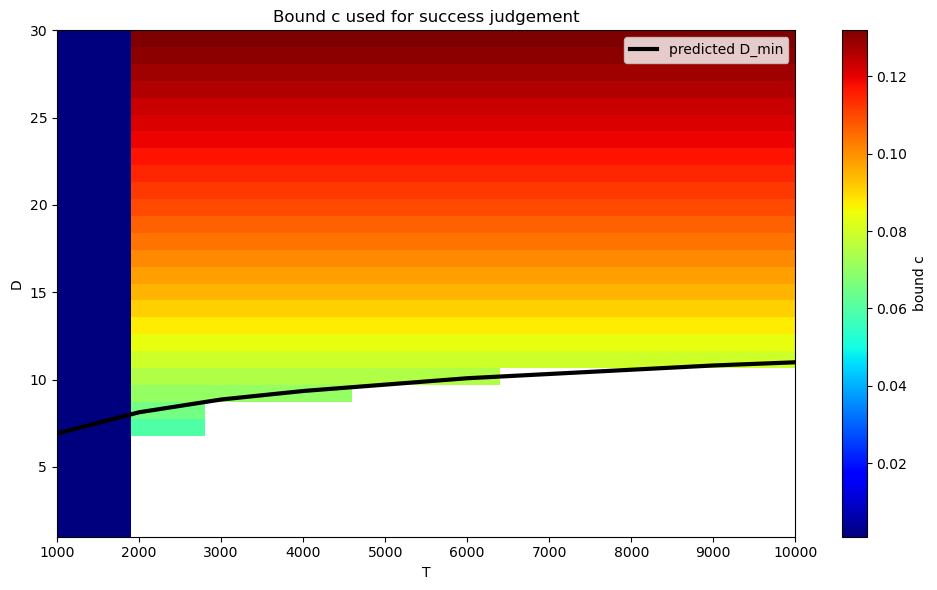

In [7]:
if c_bound is None:
    print("No c_bound file found for these parameters.")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    image = ax.imshow(
        c_bound,
        aspect="auto",
        origin="lower",
        extent=[T_values[0], T_values[-1], D_values[0], D_values[-1]],
        cmap="jet",
    )
    ax.plot(T_values, d_min_vals, linewidth=3, color="black", label="predicted D_min")
    fig.colorbar(image, ax=ax, label="bound c")
    ax.set_title("Bound c used for success judgement")
    ax.set_xlabel("T")
    ax.set_ylabel("D")
    ax.legend()
    plt.tight_layout()

## Quick Numeric Summaries

In [8]:
print("success min/mean/max:", np.nanmin(success), np.nanmean(success), np.nanmax(success))
print("D_min min/max:", np.nanmin(d_min_vals), np.nanmax(d_min_vals))

if c_bound is not None:
    print("c_bound min/mean/max:", np.nanmin(c_bound), np.nanmean(c_bound), np.nanmax(c_bound))
    print("cells with c_bound < c:", np.count_nonzero(c_bound < c))

success min/mean/max: 0.0 0.7333333333333333 1.0
D_min min/max: 6.90856934 10.98974609
c_bound min/mean/max: 0.001 0.09255437668181818 0.13188897
cells with c_bound < c: 0
